In [ ]:
# Install dependencies
!pip install -q transformers datasets torch yake nltk scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 20.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import torch
import pandas as pd
import numpy as np
import yake
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nltk.corpus import stopwords
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cuda


In [ ]:
# ============================================================================
# Step 1: Unzip classifier models from Google Drive
# ============================================================================
import zipfile
import os
import gc

DRIVE_MODEL_DIR = "/content/drive/MyDrive/modele pythia finetunate emotii"
LOCAL_MODEL_DIR = "/content/models_bee_corrected"
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

# Map config names to zip file names on Drive
MODEL_ZIPS = {
    "alpha_n":             "pythia_emotion_classifier_weighted_final (1).zip",
    "n-1_no_EmoLit":       "clf_n-1_no_Emolit (1).zip",
    "n-1_no_Emotion20":    "clf_n-1_no_Emotion20 (1).zip",
    "n-1_no_GoEmotions":   "clf_n-1_no_GoEmotions (1).zip",
    "n-1_no_XED_SMED":     "clf_n-1_no_XED_SMED (1).zip",
    "single_EmoLit":       "clf_single_EmoLit (1).zip",
    "single_Emotion20":    "clf_single_Emotion20 (1).zip",
    "single_GoEmotions":   "clf_single_GoEmotions (1).zip",
    "single_XED_SMED":     "clf_single_XED_SMED (1).zip",
}

# Clean up any previous empty extractions
import shutil
for config_name in MODEL_ZIPS:
    d = os.path.join(LOCAL_MODEL_DIR, config_name)
    if os.path.isdir(d) and not any(f.endswith(".json") for r, _, fs in os.walk(d) for f in fs):
        shutil.rmtree(d)
        print(f"Cleaned empty dir: {config_name}")

model_paths = {}
for config_name, zip_name in MODEL_ZIPS.items():
    zip_path = os.path.join(DRIVE_MODEL_DIR, zip_name)
    extract_dir = os.path.join(LOCAL_MODEL_DIR, config_name)

    # Always create the target directory first
    os.makedirs(extract_dir, exist_ok=True)

    if not any(f.endswith(".json") for f in os.listdir(extract_dir)):
        print(f"Extracting {zip_name}...")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_dir)
    else:
        print(f"Already extracted: {config_name}")

    # Find where config.json actually lives (could be nested)
    # Check top level first
    if os.path.exists(os.path.join(extract_dir, "config.json")):
        model_paths[config_name] = extract_dir
    else:
        # Search subdirectories (one level deep)
        found = False
        for item in os.listdir(extract_dir):
            sub = os.path.join(extract_dir, item)
            if os.path.isdir(sub) and os.path.exists(os.path.join(sub, "config.json")):
                model_paths[config_name] = sub
                found = True
                break
        if not found:
            # Maybe two levels deep
            for item in os.listdir(extract_dir):
                sub = os.path.join(extract_dir, item)
                if os.path.isdir(sub):
                    for item2 in os.listdir(sub):
                        sub2 = os.path.join(sub, item2)
                        if os.path.isdir(sub2) and os.path.exists(os.path.join(sub2, "config.json")):
                            model_paths[config_name] = sub2
                            found = True
                            break
                if found:
                    break
            if not found:
                print(f"  WARNING: Could not find config.json for {config_name}")
                # List what was extracted for debugging
                for root, dirs, files in os.walk(extract_dir):
                    for f in files:
                        print(f"    {os.path.join(root, f)}")
                model_paths[config_name] = extract_dir

print(f"\nAll {len(model_paths)} models extracted.")
for k, v in model_paths.items():
    print(f"  {k}: {v}")

Extracting pythia_emotion_classifier_weighted_final (1).zip...
Extracting clf_n-1_no_Emolit (1).zip...
Extracting clf_n-1_no_Emotion20 (1).zip...
Extracting clf_n-1_no_GoEmotions (1).zip...
Extracting clf_n-1_no_XED_SMED (1).zip...
Extracting clf_single_EmoLit (1).zip...
Extracting clf_single_Emotion20 (1).zip...
Extracting clf_single_GoEmotions (1).zip...
Extracting clf_single_XED_SMED (1).zip...

All 9 models extracted.
  alpha_n: /content/models_bee_corrected/alpha_n
  n-1_no_EmoLit: /content/models_bee_corrected/n-1_no_EmoLit
  n-1_no_Emotion20: /content/models_bee_corrected/n-1_no_Emotion20
  n-1_no_GoEmotions: /content/models_bee_corrected/n-1_no_GoEmotions
  n-1_no_XED_SMED: /content/models_bee_corrected/n-1_no_XED_SMED
  single_EmoLit: /content/models_bee_corrected/single_EmoLit
  single_Emotion20: /content/models_bee_corrected/single_Emotion20
  single_GoEmotions: /content/models_bee_corrected/single_GoEmotions
  single_XED_SMED: /content/models_bee_corrected/single_XED_SMED


In [ ]:
# ============================================================================
# Step 2: Extract YAKE keywords independently from each training set, then union
# Saves/loads from JSON to avoid re-running YAKE every time
# ============================================================================
import pandas as pd
import yake
import nltk
import json as _json
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

DATASET_BASE = "/content/drive/MyDrive/UPDATED_DATASETS"
YAKE_CACHE_PATH = "/content/drive/MyDrive/UPDATED_DATASETS/yake_keywords_cache.json"

# Map each config to its training dataset
DATASET_FOR_CONFIG = {
    "alpha_n":             os.path.join(DATASET_BASE, "all_4_datasets.csv"),
    "n-1_no_EmoLit":       os.path.join(DATASET_BASE, "no_EmoLit.csv"),
    "n-1_no_Emotion20":    os.path.join(DATASET_BASE, "no_EmotionDataset20.csv"),
    "n-1_no_GoEmotions":   os.path.join(DATASET_BASE, "no_GoEmotions.csv"),
    "n-1_no_XED_SMED":     os.path.join(DATASET_BASE, "no_XED_SMED.csv"),
    "single_EmoLit":       os.path.join(DATASET_BASE, "EmoLit_mapped.csv"),
    "single_Emotion20":    os.path.join(DATASET_BASE, "EmotionDataset20_mapped.csv"),
    "single_GoEmotions":   os.path.join(DATASET_BASE, "GoEmotions_mapped.csv"),
    "single_XED_SMED":     os.path.join(DATASET_BASE, "XED_and_SMED.csv"),
}

ID2LABEL = {
    0: "Angry", 1: "Anticipation", 2: "Disgust", 3: "Fear",
    4: "Happy", 5: "Neutral", 6: "Sad", 7: "Surprise", 8: "Trust"
}
LABEL_NAMES = list(ID2LABEL.values())
CANONICAL_LABELS = list(ID2LABEL.values())

filter_words = set(w.lower() for w in LABEL_NAMES)

def extract_yake_keywords(texts, top=200):
    sample_text = " ".join(str(t) for t in texts)
    extractor = yake.KeywordExtractor(lan="en", n=1, dedupLim=0.9, top=top, features=None)
    return [k[0] for k in extractor.extract_keywords(sample_text)]

# Try loading from cache first
if os.path.exists(YAKE_CACHE_PATH):
    print(f"Loading YAKE keywords from cache: {YAKE_CACHE_PATH}")
    with open(YAKE_CACHE_PATH, 'r') as f:
        per_config_keywords = _json.load(f)
    for config_name, kws in per_config_keywords.items():
        print(f"  {config_name}: {len(kws)} keywords")
else:
    print("No cache found. Extracting YAKE keywords...")
    per_config_keywords = {}
    for config_name, dataset_path in DATASET_FOR_CONFIG.items():
        df_tmp = pd.read_csv(dataset_path)
        df_tmp = df_tmp.dropna(subset=['text'])
        raw_kws = extract_yake_keywords(df_tmp['text'].tolist(), top=200)
        clean_kws = [str(k).strip() for k in raw_kws
                     if str(k).lower() not in filter_words and len(str(k).strip()) > 0]
        per_config_keywords[config_name] = clean_kws
        print(f"  {config_name}: {len(clean_kws)} keywords")

    # Save to cache
    with open(YAKE_CACHE_PATH, 'w') as f:
        _json.dump(per_config_keywords, f)
    print(f"\nSaved YAKE keywords to: {YAKE_CACHE_PATH}")

# Union of all keywords
union_keywords = sorted(set(kw for kws in per_config_keywords.values() for kw in kws))
print(f"\nUnion keyword count: {len(union_keywords)}")
print(f"Example union keywords: {union_keywords[:10]}")

Loading YAKE keywords from cache: /content/drive/MyDrive/UPDATED_DATASETS/yake_keywords_cache.json
  alpha_n: 197 keywords
  n-1_no_EmoLit: 196 keywords
  n-1_no_Emotion20: 197 keywords
  n-1_no_GoEmotions: 197 keywords
  n-1_no_XED_SMED: 197 keywords
  single_EmoLit: 198 keywords
  single_Emotion20: 198 keywords
  single_GoEmotions: 198 keywords
  single_XED_SMED: 197 keywords

Union keyword count: 535
Example union keywords: ['ASAP', 'Absolutely', 'Amazing', 'America', 'American', 'Awesome', 'Canada', 'Change', 'Check', 'Christ']


In [ ]:
# ============================================================================
# Build aligned_matrices (zero-fill) — proper per-model BEE recomputation
# Saves/loads from .npz cache to avoid recomputing every time
# ============================================================================

import torch
import numpy as np
import gc
import os
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"

ALIGNED_CACHE_PATH = "/content/drive/MyDrive/UPDATED_DATASETS/aligned_matrices_cache.npz"

def normalize_embeddings(embeddings):
    return embeddings / np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8)

def embed_text_list_batched(text_list, model, tokenizer, batch_size=64):
    model.eval()
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i : i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True,
                           max_length=128, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        if inputs['input_ids'].shape[1] == 0:
            continue
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            last_hidden = outputs.hidden_states[-1]
            mask = inputs['attention_mask']
            seq_lens = (mask.sum(dim=1) - 1).clamp(min=0)
            embeddings = last_hidden[
                torch.arange(last_hidden.size(0), device=last_hidden.device), seq_lens
            ]
            all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

keyword_to_idx = {kw: i for i, kw in enumerate(union_keywords)}

if os.path.exists(ALIGNED_CACHE_PATH):
    print(f"Loading aligned_matrices from cache: {ALIGNED_CACHE_PATH}")
    cached = np.load(ALIGNED_CACHE_PATH)
    aligned_matrices = {key: cached[key] for key in cached.files}
    for config_name, mat in aligned_matrices.items():
        nonzero_rows = np.any(mat != 0, axis=1).sum()
        print(f"  {config_name:25s}  shape={mat.shape}  nonzero_rows={nonzero_rows}")
    print(f"\nLoaded {len(aligned_matrices)} matrices from cache.")
else:
    print("No cache found. Computing aligned_matrices...")
    aligned_matrices = {}

    for config_name, mpath in model_paths.items():
        own_keywords = per_config_keywords[config_name]
        print(f"\n{'='*60}")
        print(f"Processing: {config_name} ({len(own_keywords)} own keywords)")
        print(f"{'='*60}")

        # Load model
        tokenizer = AutoTokenizer.from_pretrained(mpath)
        tokenizer.pad_token = tokenizer.eos_token
        clf_model = AutoModelForSequenceClassification.from_pretrained(mpath)
        clf_model.to(device)
        clf_model.eval()

        # Extract classifier weights
        classifier_weights = clf_model.score.weight.detach().cpu().numpy()
        classifier_weights_norm = normalize_embeddings(classifier_weights)

        # Embed only this model's OWN keywords
        kw_embeddings = embed_text_list_batched(own_keywords, clf_model, tokenizer)
        kw_embeddings_norm = normalize_embeddings(kw_embeddings)

        # Compute BEE: min-subtraction over only these keywords
        raw_sims = classifier_weights_norm @ kw_embeddings_norm.T  # (num_classes, num_own_kw)
        min_sim = raw_sims.min(axis=0, keepdims=True)
        sc_scores = raw_sims - min_sim  # all >= 0

        # Map to canonical label order
        model_num_labels = clf_model.config.num_labels
        num_own = len(own_keywords)
        own_bee = np.zeros((num_own, len(CANONICAL_LABELS)))

        if model_num_labels == len(CANONICAL_LABELS):
            own_bee = sc_scores.T  # (num_own_kw, 9)
        else:
            model_id2label = clf_model.config.id2label
            for model_idx, label_name in model_id2label.items():
                model_idx = int(model_idx)
                if label_name in CANONICAL_LABELS:
                    canon_idx = CANONICAL_LABELS.index(label_name)
                    own_bee[:, canon_idx] = sc_scores[model_idx, :]

        # Zero-fill into union structure
        aligned = np.zeros((len(union_keywords), len(CANONICAL_LABELS)))
        for local_idx, kw in enumerate(own_keywords):
            if kw in keyword_to_idx:
                aligned[keyword_to_idx[kw], :] = own_bee[local_idx, :]

        aligned_matrices[config_name] = aligned

        nonzero_rows = np.any(aligned != 0, axis=1).sum()
        print(f"  BEE computed over {num_own} own keywords, zero-filled into {aligned.shape}")
        print(f"  Non-zero rows: {nonzero_rows}/{len(union_keywords)}")

        # Free memory
        del clf_model, tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Save to cache
    np.savez(ALIGNED_CACHE_PATH, **aligned_matrices)
    print(f"\nSaved aligned_matrices to: {ALIGNED_CACHE_PATH}")

print(f"\nDone! {len(aligned_matrices)} models, shape: {aligned_matrices['alpha_n'].shape}")

Loading aligned_matrices from cache: /content/drive/MyDrive/UPDATED_DATASETS/aligned_matrices_cache.npz
  alpha_n                    shape=(535, 9)  nonzero_rows=197
  n-1_no_EmoLit              shape=(535, 9)  nonzero_rows=196
  n-1_no_Emotion20           shape=(535, 9)  nonzero_rows=197
  n-1_no_GoEmotions          shape=(535, 9)  nonzero_rows=197
  n-1_no_XED_SMED            shape=(535, 9)  nonzero_rows=197
  single_EmoLit              shape=(535, 9)  nonzero_rows=198
  single_Emotion20           shape=(535, 9)  nonzero_rows=198
  single_GoEmotions          shape=(535, 9)  nonzero_rows=198
  single_XED_SMED            shape=(535, 9)  nonzero_rows=197

Loaded 9 matrices from cache.

Done! 9 models, shape: (535, 9)


Leave-One-Out MIA — Zero-Fill BEE Cosine Similarity
Dataset              Member   Non-member    Delta   Hit
-------------------------------------------------------
EmoLit               0.5331       0.2625  +0.2705     Y
Emotion20            0.3327       0.2626  +0.0701     Y
GoEmotions           0.4244       0.3868  +0.0375     Y
XED_SMED             0.4230       0.3250  +0.0980     Y

Flat accuracy: 100% (4/4)
Per-emotion accuracy: 91.7% (33/36)

Contribution Match: cos_sim(alpha_n - alpha_{n-1,no_i}, single_i)
  EmoLit: 0.2435
  Emotion20: 0.0182
  GoEmotions: -0.1561
  XED_SMED: 0.1471


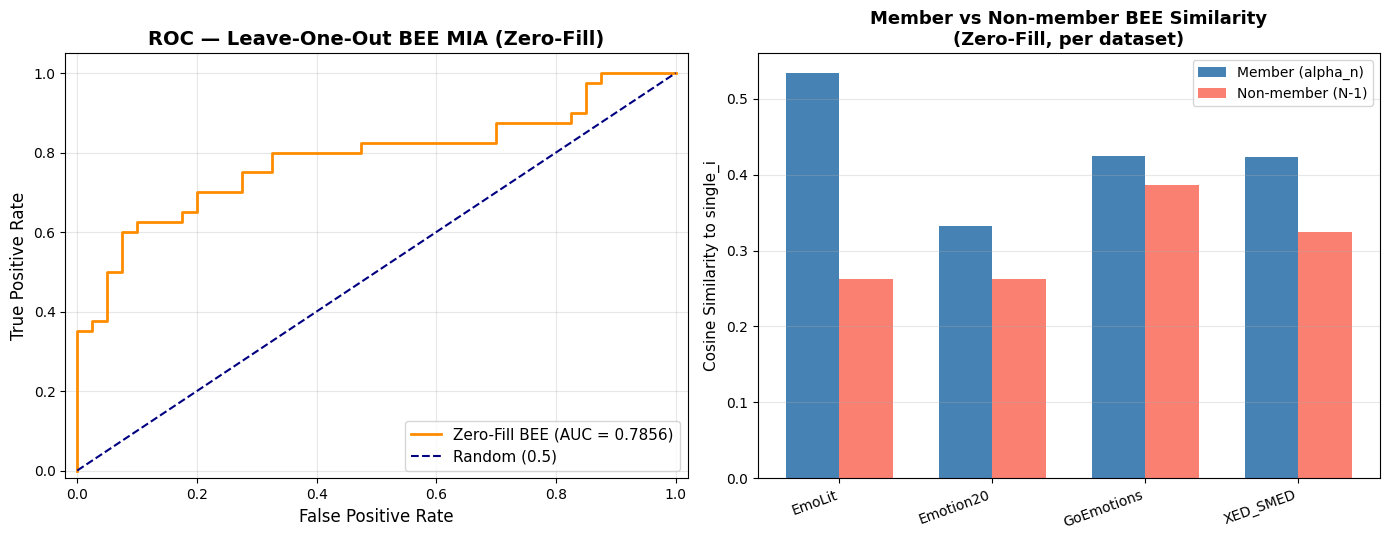


Leave-One-Out BEE MIA (Zero-Fill)  —  AUC = 0.7856


In [ ]:
# ============================================================================
# Leave-One-Out MIA — ROC / AUC  (Zero-Fill BEE)
# ============================================================================
# Using aligned_matrices (zero-fill) instead of corrected_matrices.
# Zero-fill = each model keeps only its OWN keywords, zeros for the rest.
# This amplifies structural differences between training configurations.
# ============================================================================

from sklearn.metrics import roc_curve, auc
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine_sim
DATASET_NAMES = ["EmoLit", "Emotion20", "GoEmotions", "XED_SMED"]
N1_KEYS = ["n-1_no_EmoLit", "n-1_no_Emotion20", "n-1_no_GoEmotions", "n-1_no_XED_SMED"]
SINGLE_KEYS = ["single_EmoLit", "single_Emotion20", "single_GoEmotions", "single_XED_SMED"]
alpha_n_zf = aligned_matrices["alpha_n"]

# ── (A) Per-dataset flat scores ──
print("="*65)
print("Leave-One-Out MIA — Zero-Fill BEE Cosine Similarity")
print("="*65)
print(f"{'Dataset':<16} {'Member':>10} {'Non-member':>12} {'Delta':>8} {'Hit':>5}")
print("-"*55)

member_flat = []
nonmember_flat = []
for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    single_flat = aligned_matrices[s_key].flatten().reshape(1, -1)
    alpha_flat  = alpha_n_zf.flatten().reshape(1, -1)
    n1_flat     = aligned_matrices[n1_key].flatten().reshape(1, -1)

    m_score  = sklearn_cosine_sim(alpha_flat, single_flat)[0, 0]
    nm_score = sklearn_cosine_sim(n1_flat, single_flat)[0, 0]
    member_flat.append(m_score)
    nonmember_flat.append(nm_score)

    hit = "Y" if m_score > nm_score else " "
    print(f"{name:<16} {m_score:>10.4f} {nm_score:>12.4f} {m_score - nm_score:>+8.4f} {hit:>5}")

flat_accuracy = sum(m > n for m, n in zip(member_flat, nonmember_flat)) / len(DATASET_NAMES)
print(f"\nFlat accuracy: {flat_accuracy:.0%} ({sum(m > n for m, n in zip(member_flat, nonmember_flat))}/{len(DATASET_NAMES)})")

# ── (B) Per-emotion scores → ROC/AUC ──
member_scores = []
nonmember_scores = []

for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    for c_idx in range(len(CANONICAL_LABELS)):
        single_col = aligned_matrices[s_key][:, c_idx].reshape(1, -1)
        alpha_col  = alpha_n_zf[:, c_idx].reshape(1, -1)
        n1_col     = aligned_matrices[n1_key][:, c_idx].reshape(1, -1)

        if np.linalg.norm(single_col) < 1e-10:
            continue

        m_s  = sklearn_cosine_sim(alpha_col, single_col)[0, 0] if np.linalg.norm(alpha_col) > 1e-10 else 0.0#matrice 9 x 535 pe single si alpha_n (member)
        nm_s = sklearn_cosine_sim(n1_col, single_col)[0, 0]    if np.linalg.norm(n1_col) > 1e-10 else 0.0#matrice 9x535 pe n-1 si single (non member)
        member_scores.append(m_s)
        nonmember_scores.append(nm_s)

all_member    = member_flat + member_scores
all_nonmember = nonmember_flat + nonmember_scores

scores = np.array(all_member + all_nonmember) #cos similarity (and later pearson) 0.8,0.6,0.5,0.9,0.2,0.5,0.1  ; roc_curve sorts these
labels = np.array([1]*len(all_member) + [0]*len(all_nonmember)) #ground truth -> 1,1,1,1,0,0,0

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

emo_hits = sum(m > n for m, n in zip(member_scores, nonmember_scores))
emo_total = len(member_scores)
print(f"Per-emotion accuracy: {emo_hits/emo_total:.1%} ({emo_hits}/{emo_total})")

# ── (C) Contribution-match score ──
print(f"\n{'='*65}")
print("Contribution Match: cos_sim(alpha_n - alpha_{n-1,no_i}, single_i)")
print("="*65)
for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    contrib = (alpha_n_zf - aligned_matrices[n1_key]).flatten().reshape(1, -1)
    single  = aligned_matrices[s_key].flatten().reshape(1, -1)
    cs = sklearn_cosine_sim(contrib, single)[0, 0]
    print(f"  {name}: {cs:.4f}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"Zero-Fill BEE (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random (0.5)")
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC — Leave-One-Out BEE MIA (Zero-Fill)", fontsize=14, fontweight="bold")
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, alpha=0.3)

x = np.arange(len(DATASET_NAMES))
w = 0.35
axes[1].bar(x - w/2, member_flat, w, label="Member (alpha_n)", color="steelblue")
axes[1].bar(x + w/2, nonmember_flat, w, label="Non-member (N-1)", color="salmon")
axes[1].set_xticks(x)
axes[1].set_xticklabels(DATASET_NAMES, rotation=20, ha="right")
axes[1].set_ylabel("Cosine Similarity to single_i", fontsize=11)
axes[1].set_title("Member vs Non-member BEE Similarity\n(Zero-Fill, per dataset)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("BEE_MIA_LOO_ROC_AUC.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*65}")
print(f"Leave-One-Out BEE MIA (Zero-Fill)  —  AUC = {roc_auc:.4f}")
print(f"{'='*65}")

Computing softmax BEE (zero-fill) for all models...
  alpha_n (197 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  n-1_no_EmoLit (196 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  n-1_no_Emotion20 (197 keywords)...


...

  single_GoEmotions (198 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  single_XED_SMED (197 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


All softmax BEE matrices computed. Shape: (535, 9)

Correlation: White-Box vs Softmax BEE (both Zero-Fill)
Model                       Pearson   Cosine
----------------------------------------------
  alpha_n                    0.6733   0.6912
  n-1_no_EmoLit              0.6537   0.6786
  n-1_no_Emotion20           0.6071   0.6336
  n-1_no_GoEmotions          0.6351   0.6651
  n-1_no_XED_SMED            0.6747   0.6857
  single_EmoLit              0.6219   0.6588
  single_Emotion20           0.6298   0.6559
  single_GoEmotions          0.6205   0.6485
  single_XED_SMED            0.6752   0.7121

Leave-One-Out MIA — Softmax Zero-Fill BEE
Dataset              Member   Non-member    Delta   Hit
-------------------------------------------------------
EmoLit               0.1739       0.0878  +0.0861     Y
Emotion20            0.0869       0.0504  +0.0365     Y
GoEmotions           0.4448       0.3644  +0.0804     Y
XED_SMED             0.3758       0.2549  +0.1208     Y

Flat accuracy: 

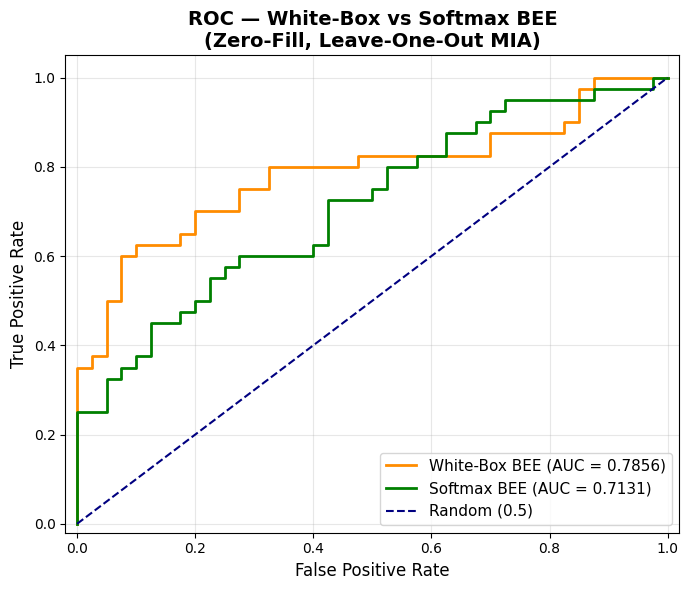


White-Box BEE AUC = 0.7856   |   Softmax BEE AUC = 0.7131


In [ ]:
# ============================================================================
# Black-Box Softmax BEE — Zero-Fill, No Weight Extraction
# ============================================================================

import torch
import torch.nn.functional as F
import gc

device = "cuda" if torch.cuda.is_available() else "cpu"

keyword_to_idx = {kw: i for i, kw in enumerate(union_keywords)}

def compute_softmax_bee_zerofill(model_path, own_keywords, batch_size=64):
    """
    Black-box BEE with zero-fill: compute softmax only for the model's OWN
    keywords, zero-fill the rest.
    Returns (len(union_keywords), 9) matrix.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    model_id2label = model.config.id2label
    num_model_labels = model.config.num_labels

    # Only process this model's own keywords
    all_probs = []
    for i in range(0, len(own_keywords), batch_size):
        batch = own_keywords[i : i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                           max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    raw_probs = np.vstack(all_probs)  # (num_own_keywords, num_model_labels)

    # Min-subtract per class
    raw_probs = raw_probs - raw_probs.min(axis=1, keepdims=True)  # min per keyword over classes

    # Zero-fill into union keyword x canonical label matrix
    softmax_matrix = np.zeros((len(union_keywords), len(CANONICAL_LABELS)))
    for local_idx, kw in enumerate(own_keywords):
        if kw not in keyword_to_idx:
            continue
        global_idx = keyword_to_idx[kw]
        if num_model_labels == len(CANONICAL_LABELS):
            softmax_matrix[global_idx, :] = raw_probs[local_idx, :]
        else:
            for model_class_idx, label_name in model_id2label.items():
                model_class_idx = int(model_class_idx)
                if label_name in CANONICAL_LABELS:
                    canon_idx = CANONICAL_LABELS.index(label_name)
                    softmax_matrix[global_idx, canon_idx] = raw_probs[local_idx, model_class_idx]

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return softmax_matrix

# ── Compute softmax BEE (zero-fill) for all models ──
print("Computing softmax BEE (zero-fill) for all models...")
softmax_zf = {}

for config_name, mpath in model_paths.items():
    own_kws = per_config_keywords[config_name]
    print(f"  {config_name} ({len(own_kws)} keywords)...")
    softmax_zf[config_name] = compute_softmax_bee_zerofill(mpath, own_kws)

print(f"\nAll softmax BEE matrices computed. Shape: {softmax_zf['alpha_n'].shape}")

# ── Validate: correlation white-box vs softmax (zero-fill) ──
print("\n" + "="*60)
print("Correlation: White-Box vs Softmax BEE (both Zero-Fill)")
print("="*60)
print(f"{'Model':<26} {'Pearson':>8} {'Cosine':>8}")
print("-"*46)

for config_name in model_paths:
    wb_flat = aligned_matrices[config_name].flatten()
    sb_flat = softmax_zf[config_name].flatten()
    if np.linalg.norm(wb_flat) < 1e-10 or np.linalg.norm(sb_flat) < 1e-10:
        print(f"  {config_name:<24} {'N/A':>8} {'N/A':>8}")
        continue
    pearson_r = np.corrcoef(wb_flat, sb_flat)[0, 1]
    cos_s = sklearn_cosine_sim(wb_flat.reshape(1, -1), sb_flat.reshape(1, -1))[0, 0]
    print(f"  {config_name:<24} {pearson_r:>8.4f} {cos_s:>8.4f}")

# ── Leave-one-out MIA with softmax zero-fill ──
print("\n" + "="*60)
print("Leave-One-Out MIA — Softmax Zero-Fill BEE")
print("="*60)

alpha_sb = softmax_zf["alpha_n"]

sb_member_flat = []
sb_nonmember_flat = []
sb_member_emo = []
sb_nonmember_emo = []

print(f"{'Dataset':<16} {'Member':>10} {'Non-member':>12} {'Delta':>8} {'Hit':>5}")
print("-"*55)

for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    single_sb = softmax_zf[s_key].flatten().reshape(1, -1)
    alpha_sb_flat = alpha_sb.flatten().reshape(1, -1)
    n1_sb = softmax_zf[n1_key].flatten().reshape(1, -1)

    m_s  = sklearn_cosine_sim(alpha_sb_flat, single_sb)[0, 0]
    nm_s = sklearn_cosine_sim(n1_sb, single_sb)[0, 0]
    sb_member_flat.append(m_s)
    sb_nonmember_flat.append(nm_s)

    hit = "Y" if m_s > nm_s else " "
    print(f"{name:<16} {m_s:>10.4f} {nm_s:>12.4f} {m_s - nm_s:>+8.4f} {hit:>5}")

    for c_idx in range(len(CANONICAL_LABELS)):
        s_col = softmax_zf[s_key][:, c_idx].reshape(1, -1)
        a_col = alpha_sb[:, c_idx].reshape(1, -1)
        n_col = softmax_zf[n1_key][:, c_idx].reshape(1, -1)
        if np.linalg.norm(s_col) < 1e-10:
            continue
        sb_member_emo.append(
            sklearn_cosine_sim(a_col, s_col)[0, 0] if np.linalg.norm(a_col) > 1e-10 else 0.0
        )
        sb_nonmember_emo.append(
            sklearn_cosine_sim(n_col, s_col)[0, 0] if np.linalg.norm(n_col) > 1e-10 else 0.0
        )

sb_all_m  = sb_member_flat + sb_member_emo
sb_all_nm = sb_nonmember_flat + sb_nonmember_emo
sb_scores = np.array(sb_all_m + sb_all_nm)
sb_labels = np.array([1]*len(sb_all_m) + [0]*len(sb_all_nm))

sb_fpr, sb_tpr, _ = roc_curve(sb_labels, sb_scores)
sb_auc = auc(sb_fpr, sb_tpr)

sb_flat_acc = sum(m > n for m, n in zip(sb_member_flat, sb_nonmember_flat)) / len(DATASET_NAMES)
sb_emo_hits = sum(m > n for m, n in zip(sb_member_emo, sb_nonmember_emo))
print(f"\nFlat accuracy: {sb_flat_acc:.0%}")
if len(sb_member_emo) > 0:
    print(f"Per-emotion accuracy: {sb_emo_hits/len(sb_member_emo):.1%} ({sb_emo_hits}/{len(sb_member_emo)})")

# ── Plot both ROC curves ──
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"White-Box BEE (AUC = {roc_auc:.4f})")
ax.plot(sb_fpr, sb_tpr, color="green", lw=2, label=f"Softmax BEE (AUC = {sb_auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random (0.5)")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC — White-Box vs Softmax BEE\n(Zero-Fill, Leave-One-Out MIA)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("BEE_MIA_ROC_whitebox_vs_softmax.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*60}")
print(f"White-Box BEE AUC = {roc_auc:.4f}   |   Softmax BEE AUC = {sb_auc:.4f}")
print(f"{'='*60}")

Pairwise Cosine Similarity: Single-Dataset BEE Fingerprints (Zero-Fill)
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit      1.0000     0.1618      0.2495    0.2040
Emotion20   0.1618     1.0000      0.2733    0.2707
GoEmotions  0.2495     0.2733      1.0000    0.4356
XED_SMED    0.2040     0.2707      0.4356    1.0000

Contribution_i vs Single_j — Cosine Similarity (Zero-Fill)
(Diagonal = self-match, should be highest per row)
                    Single EmoLit  Single Emotion20  Single GoEmotions  Single XED_SMED
Contrib EmoLit             0.2435           -0.1744            -0.1447          -0.2097
Contrib Emotion20         -0.2233            0.0182            -0.1011          -0.0991
Contrib GoEmotions        -0.3983           -0.1816            -0.1561          -0.2002
Contrib XED_SMED          -0.1956            0.0788             0.0853           0.1471
Diagonal-dominant rows: 4/4

Contribution_i vs Single_j — Pearson Correlation (Zero-Fill)
(Diagonal = self-match, sho

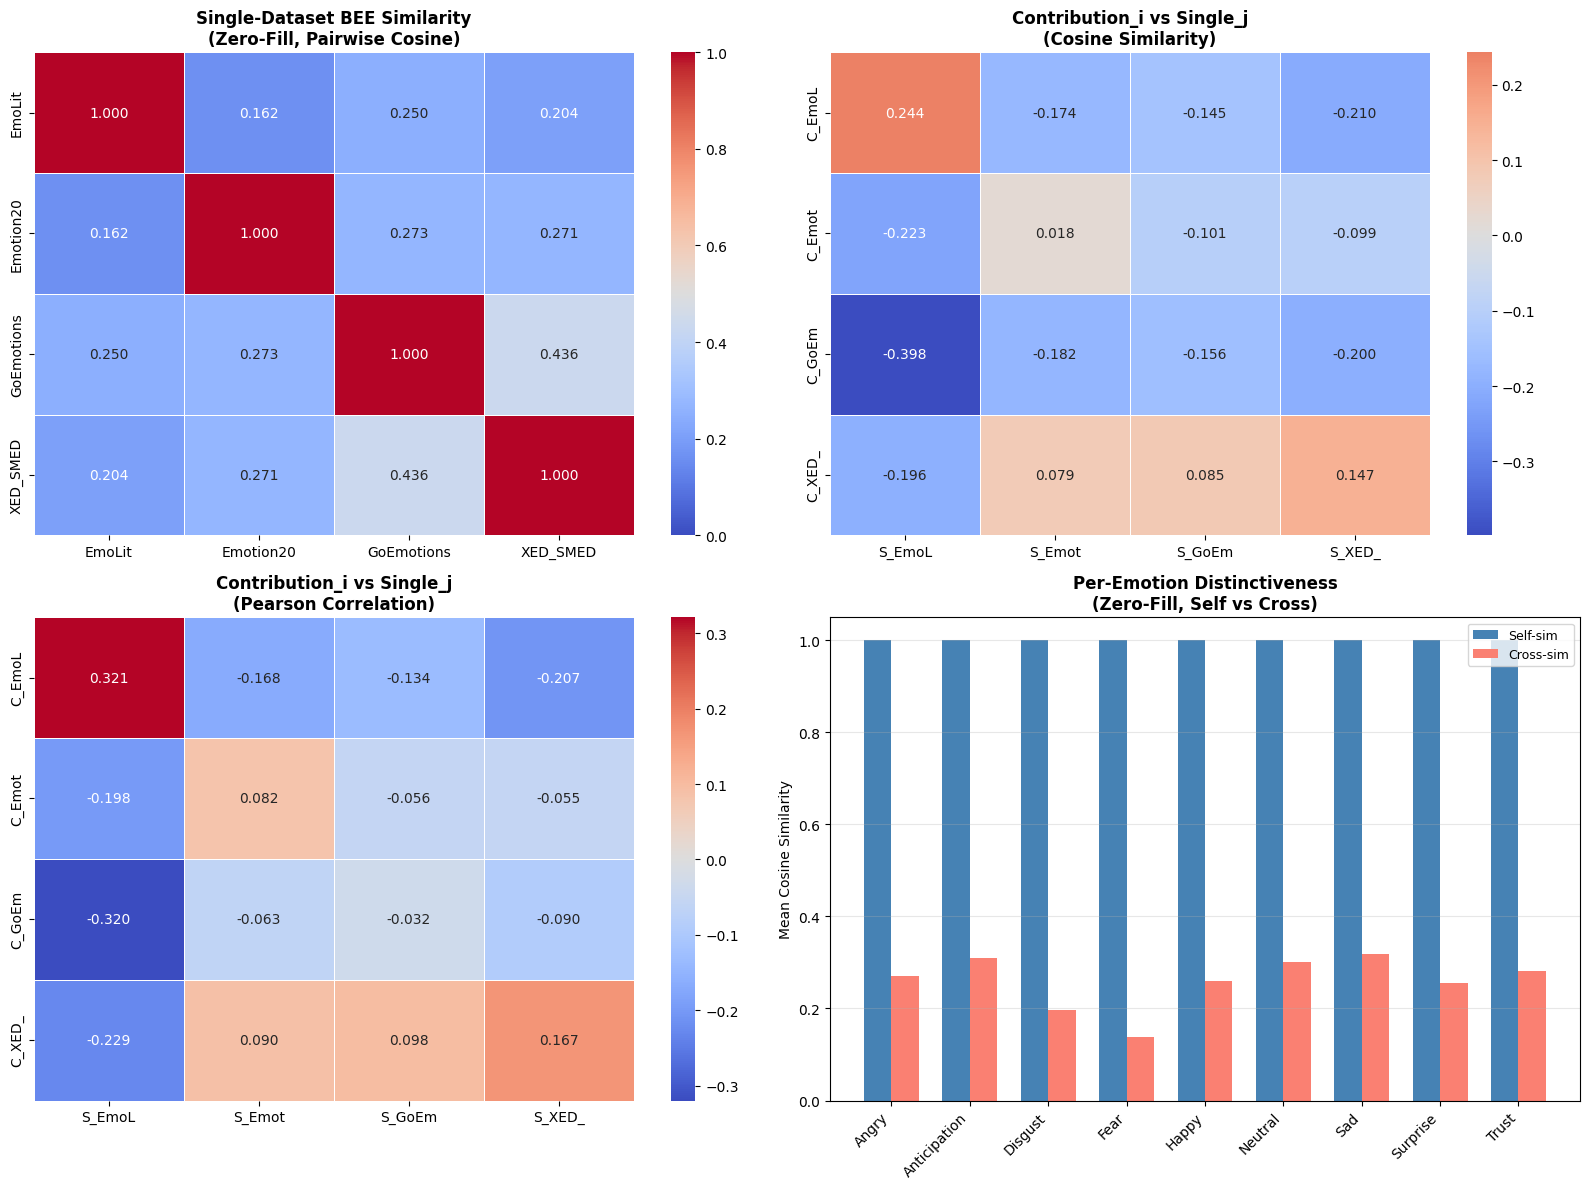


Conclusion: Each dataset produces a distinct BEE fingerprint.
Zero-fill structure amplifies keyword-set differences between training configs.


In [ ]:
# ============================================================================
# Dataset Fingerprint Stability — Zero-Fill BEE
# ============================================================================

num_datasets = len(DATASET_NAMES)

# ── (A) Pairwise similarity: single_i vs single_j ──
single_pairwise = np.zeros((num_datasets, num_datasets))
for i in range(num_datasets):
    vec_i = aligned_matrices[SINGLE_KEYS[i]].flatten().reshape(1, -1)
    for j in range(num_datasets):
        vec_j = aligned_matrices[SINGLE_KEYS[j]].flatten().reshape(1, -1)
        single_pairwise[i, j] = sklearn_cosine_sim(vec_i, vec_j)[0, 0]

print("Pairwise Cosine Similarity: Single-Dataset BEE Fingerprints (Zero-Fill)")
print(pd.DataFrame(single_pairwise,
    index=DATASET_NAMES, columns=DATASET_NAMES
).to_string(float_format="{:.4f}".format))

# ── (B) Cross-model consistency: contribution_i vs single_j ──
# Cosine similarity
print(f"\n{'='*65}")
print("Contribution_i vs Single_j — Cosine Similarity (Zero-Fill)")
print("(Diagonal = self-match, should be highest per row)")
print("="*65)

alpha_n_zf = aligned_matrices["alpha_n"]
contrib_vs_single_cos = np.zeros((num_datasets, num_datasets))
contrib_vs_single_pear = np.zeros((num_datasets, num_datasets))

for i, (name_i, n1_key) in enumerate(zip(DATASET_NAMES, N1_KEYS)):
    contrib_i = (alpha_n_zf - aligned_matrices[n1_key]).flatten()
    for j, s_key in enumerate(SINGLE_KEYS):
        single_j = aligned_matrices[s_key].flatten()
        contrib_vs_single_cos[i, j] = sklearn_cosine_sim(
            contrib_i.reshape(1, -1), single_j.reshape(1, -1)
        )[0, 0]
        contrib_vs_single_pear[i, j] = np.corrcoef(contrib_i, single_j)[0, 1]

contrib_cos_df = pd.DataFrame(contrib_vs_single_cos,
    index=[f"Contrib {n}" for n in DATASET_NAMES],
    columns=[f"Single {n}" for n in DATASET_NAMES])
print(contrib_cos_df.to_string(float_format="{:.4f}".format))

diag_dominant_cos = sum(1 for i in range(num_datasets) if np.argmax(contrib_vs_single_cos[i]) == i)
print(f"Diagonal-dominant rows: {diag_dominant_cos}/{num_datasets}")

# Pearson correlation
print(f"\n{'='*65}")
print("Contribution_i vs Single_j — Pearson Correlation (Zero-Fill)")
print("(Diagonal = self-match, should be highest per row)")
print("="*65)

contrib_pear_df = pd.DataFrame(contrib_vs_single_pear,
    index=[f"Contrib {n}" for n in DATASET_NAMES],
    columns=[f"Single {n}" for n in DATASET_NAMES])
print(contrib_pear_df.to_string(float_format="{:.4f}".format))

diag_dominant_pear = sum(1 for i in range(num_datasets) if np.argmax(contrib_vs_single_pear[i]) == i)
print(f"Diagonal-dominant rows: {diag_dominant_pear}/{num_datasets}")

# ── (C) Per-emotion fingerprint distinctiveness ──
print(f"\n{'='*65}")
print("Per-Emotion Fingerprint Distinctiveness (Zero-Fill)")
print("="*65)

emotion_stats = []
for c_idx, c_name in enumerate(CANONICAL_LABELS):
    emo_sim = np.zeros((num_datasets, num_datasets))
    for i in range(num_datasets):
        col_i = aligned_matrices[SINGLE_KEYS[i]][:, c_idx].reshape(1, -1)
        for j in range(num_datasets):
            col_j = aligned_matrices[SINGLE_KEYS[j]][:, c_idx].reshape(1, -1)
            if np.linalg.norm(col_i) < 1e-10 or np.linalg.norm(col_j) < 1e-10:
                emo_sim[i, j] = 0.0
            else:
                emo_sim[i, j] = sklearn_cosine_sim(col_i, col_j)[0, 0]

    diag_mean = np.mean(np.diag(emo_sim))
    off_diag = emo_sim[~np.eye(num_datasets, dtype=bool)]
    off_diag_mean = np.mean(off_diag)
    emotion_stats.append({
        "Emotion": c_name,
        "Self": diag_mean,
        "Cross": off_diag_mean,
        "Gap": diag_mean - off_diag_mean,
    })

dominance_df = pd.DataFrame(emotion_stats)
print(dominance_df.to_string(index=False, float_format="{:.4f}".format))

# ── Summary ──
diag_vals = np.diag(single_pairwise)
off_diag_vals = single_pairwise[~np.eye(num_datasets, dtype=bool)]

print(f"\n{'='*65}")
print(f"Dataset Fingerprint Stability — Summary (Zero-Fill)")
print(f"{'='*65}")
print(f"  Self-similarity  (diagonal mean):     {np.mean(diag_vals):.4f}")
print(f"  Cross-similarity (off-diagonal mean):  {np.mean(off_diag_vals):.4f}")
print(f"  Gap:                                   {np.mean(diag_vals) - np.mean(off_diag_vals):.4f}")
print(f"  Mean per-emotion gap:                  {dominance_df['Gap'].mean():.4f}")

# ── Visualization ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Single pairwise heatmap
sns.heatmap(single_pairwise, annot=True, fmt=".3f", cmap="coolwarm",
    xticklabels=DATASET_NAMES, yticklabels=DATASET_NAMES,
    vmin=0, vmax=1, ax=axes[0, 0], linewidths=0.5, linecolor="white")
axes[0, 0].set_title("Single-Dataset BEE Similarity\n(Zero-Fill, Pairwise Cosine)", fontsize=12, fontweight="bold")

# (2) Contribution vs Single — Cosine
sns.heatmap(contrib_vs_single_cos, annot=True, fmt=".3f", cmap="coolwarm",
    xticklabels=[f"S_{n[:4]}" for n in DATASET_NAMES],
    yticklabels=[f"C_{n[:4]}" for n in DATASET_NAMES],
    center=0, ax=axes[0, 1], linewidths=0.5, linecolor="white")
axes[0, 1].set_title("Contribution_i vs Single_j\n(Cosine Similarity)", fontsize=12, fontweight="bold")

# (3) Contribution vs Single — Pearson
sns.heatmap(contrib_vs_single_pear, annot=True, fmt=".3f", cmap="coolwarm",
    xticklabels=[f"S_{n[:4]}" for n in DATASET_NAMES],
    yticklabels=[f"C_{n[:4]}" for n in DATASET_NAMES],
    center=0, ax=axes[1, 0], linewidths=0.5, linecolor="white")
axes[1, 0].set_title("Contribution_i vs Single_j\n(Pearson Correlation)", fontsize=12, fontweight="bold")

# (4) Per-emotion distinctiveness
emotions = dominance_df["Emotion"]
x = np.arange(len(emotions))
w = 0.35
axes[1, 1].bar(x - w/2, dominance_df["Self"], w, label="Self-sim", color="steelblue")
axes[1, 1].bar(x + w/2, dominance_df["Cross"], w, label="Cross-sim", color="salmon")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(emotions, rotation=45, ha="right")
axes[1, 1].set_ylabel("Mean Cosine Similarity")
axes[1, 1].set_title("Per-Emotion Distinctiveness\n(Zero-Fill, Self vs Cross)", fontsize=12, fontweight="bold")
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("BEE_dataset_fingerprint_stability.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nConclusion: Each dataset produces a distinct BEE fingerprint.")
print("Zero-fill structure amplifies keyword-set differences between training configs.")


Angry:
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit      0.3768    -0.1844     -0.1618   -0.1797
Emotion20  -0.1468     0.1110     -0.0417   -0.0775
GoEmotions -0.2411    -0.0656      0.0031   -0.0552
XED_SMED   -0.0605     0.1030      0.1500    0.1553

Anticipation:
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit      0.3398    -0.2239     -0.2078   -0.2885
Emotion20  -0.2442     0.0936     -0.1286   -0.0678
GoEmotions -0.3209    -0.1043     -0.0598   -0.1015
XED_SMED   -0.3319    -0.0262     -0.0639   -0.0372

Disgust:
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit      0.2565    -0.2078     -0.2518   -0.1796
Emotion20  -0.2280     0.1425     -0.0991   -0.0109
GoEmotions -0.3404     0.0380     -0.0287   -0.0365
XED_SMED   -0.4948     0.0738     -0.0718    0.0127

Fear:
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit      0.1139    -0.0569     -0.0498   -0.0784
Emotion20  -0.0557     0.0052      0.0884    0.0647
GoEmotions -0.1414     0

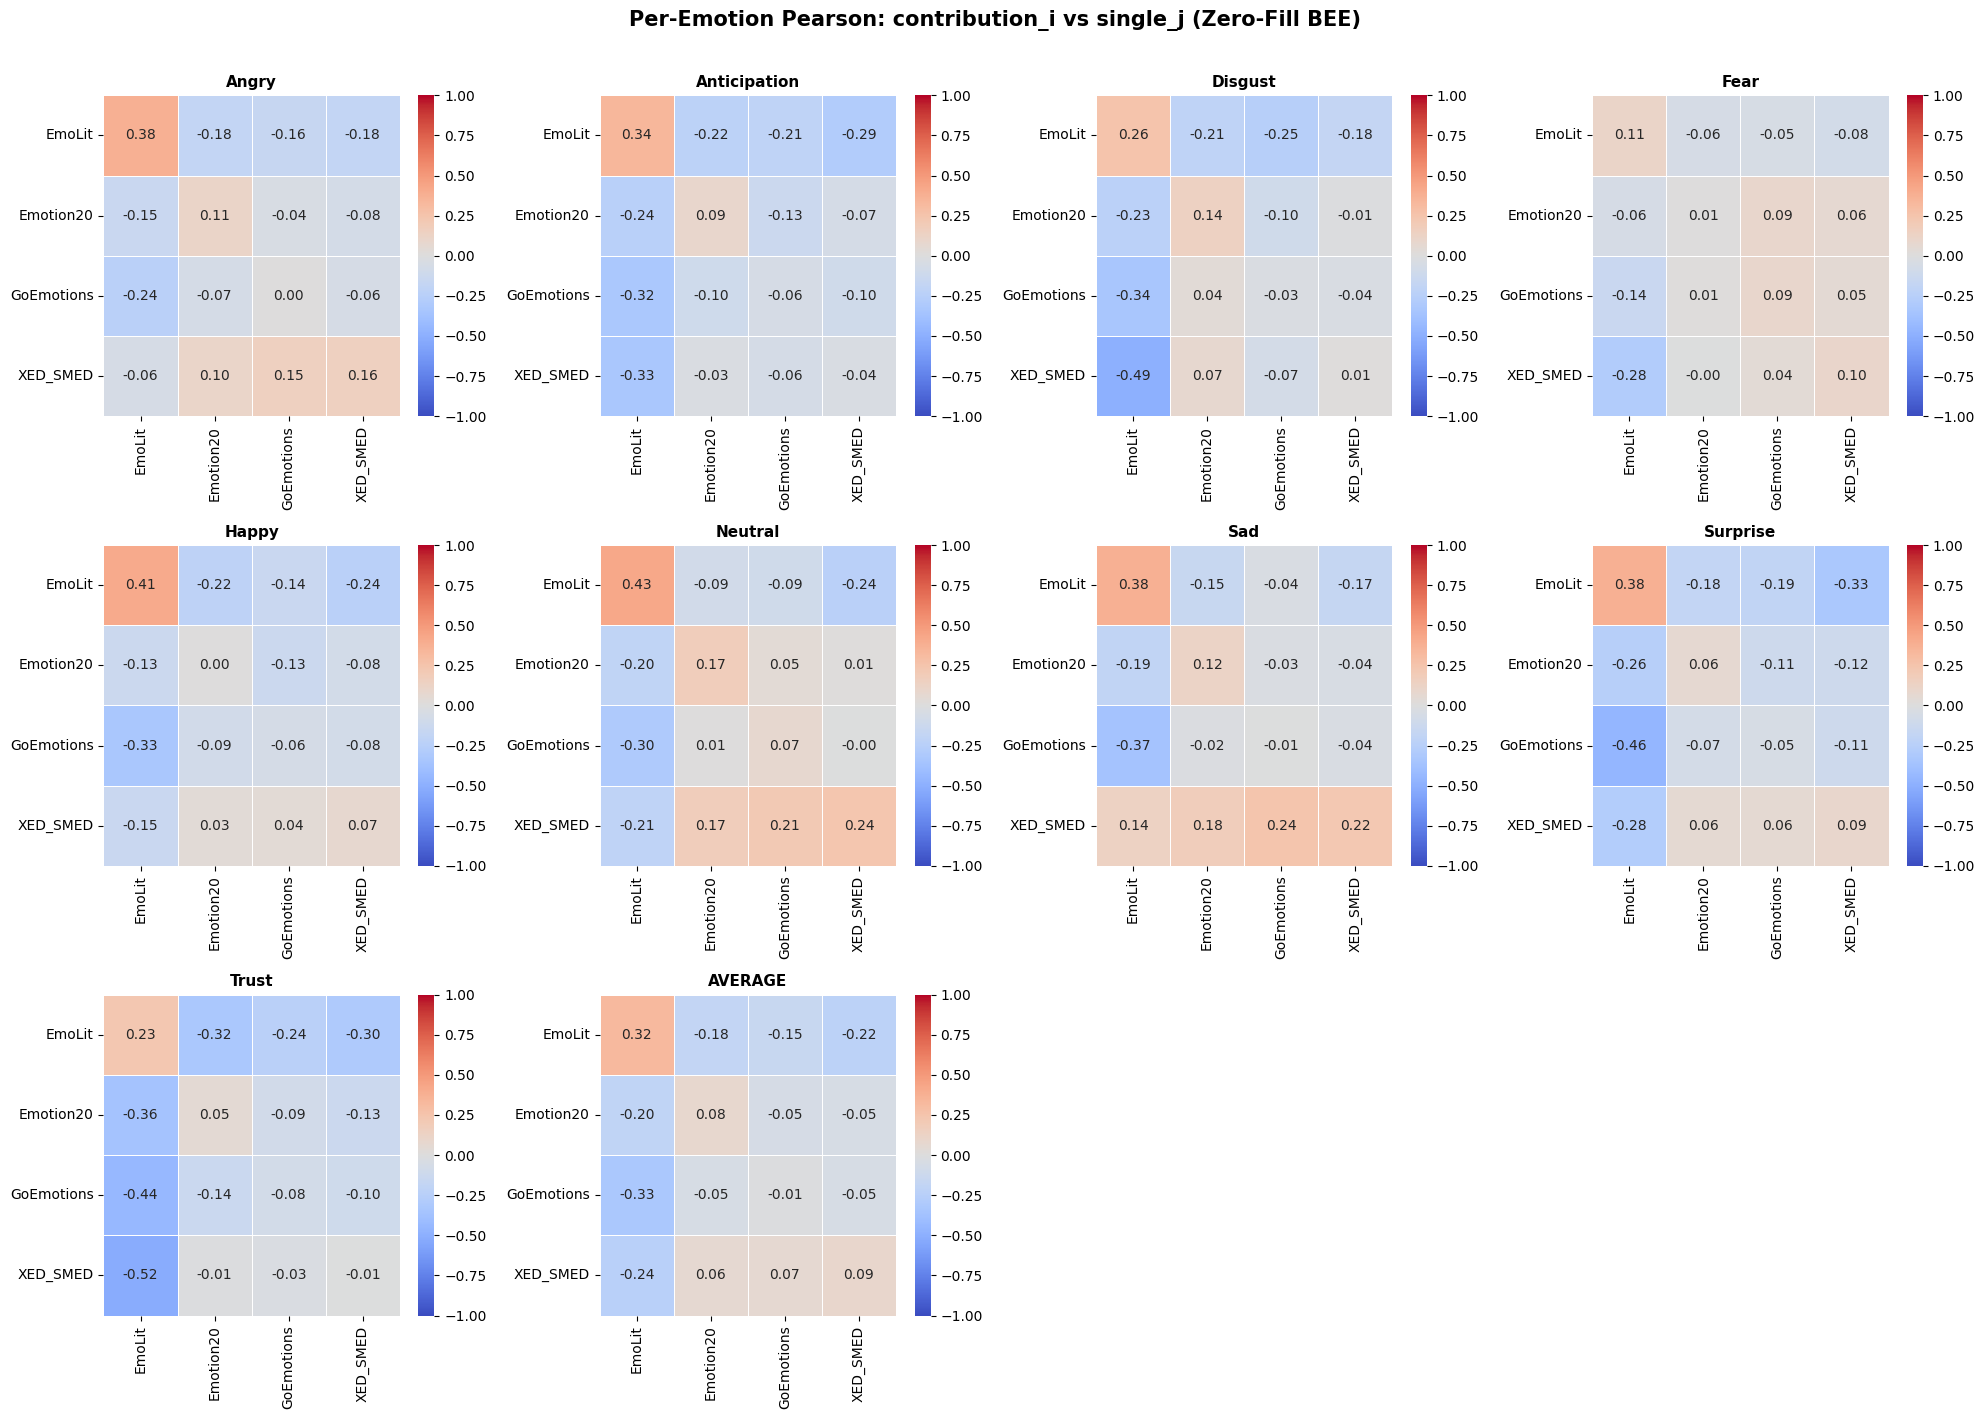

In [ ]:
# ============================================================================
# Per-Emotion Pearson: contribution_i vs single_j, then average
# ============================================================================
# For each emotion: 4x4 Pearson matrix between contribution_i and single_j
# Then average all 9 matrices element-wise.
# ============================================================================

alpha_n_zf = aligned_matrices["alpha_n"]
num_datasets = len(DATASET_NAMES)
num_emotions = len(CANONICAL_LABELS)

per_emotion_pearson = {}

for c_idx, c_name in enumerate(CANONICAL_LABELS):
    P = np.zeros((num_datasets, num_datasets))
    for i, (name_i, n1_key) in enumerate(zip(DATASET_NAMES, N1_KEYS)):
        contrib_col = alpha_n_zf[:, c_idx] - aligned_matrices[n1_key][:, c_idx]
        for j, s_key in enumerate(SINGLE_KEYS):
            single_col = aligned_matrices[s_key][:, c_idx]
            if np.std(contrib_col) < 1e-10 or np.std(single_col) < 1e-10:
                P[i, j] = 0.0
            else:
                P[i, j] = np.corrcoef(contrib_col, single_col)[0, 1]
    per_emotion_pearson[c_name] = P

# Average across all emotions
avg_pearson = np.mean([per_emotion_pearson[c] for c in CANONICAL_LABELS], axis=0)

# ── Print per-emotion matrices ──
for c_name in CANONICAL_LABELS:
    P = per_emotion_pearson[c_name]
    print(f"\n{c_name}:")
    print(pd.DataFrame(P, index=DATASET_NAMES, columns=DATASET_NAMES).to_string(float_format="{:.4f}".format))

# ── Print average ──
print(f"\n{'='*65}")
print("Average Pearson(contribution_i, single_j) across all emotions")
print("="*65)
avg_df = pd.DataFrame(avg_pearson, index=DATASET_NAMES, columns=DATASET_NAMES)
print(avg_df.to_string(float_format="{:.4f}".format))

diag_dominant = sum(1 for i in range(num_datasets) if np.argmax(avg_pearson[i]) == i)
print(f"\nDiagonal-dominant rows: {diag_dominant}/{num_datasets}")

# ── Visualize ──
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

# 9 per-emotion heatmaps
for idx, c_name in enumerate(CANONICAL_LABELS):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    sns.heatmap(per_emotion_pearson[c_name], annot=True, fmt=".2f", cmap="coolwarm",
        center=0, vmin=-1, vmax=1,
        xticklabels=DATASET_NAMES, yticklabels=DATASET_NAMES,
        ax=ax, linewidths=0.5, linecolor="white")
    ax.set_title(c_name, fontsize=11, fontweight="bold")

# 10th subplot: average
ax_avg = axes[2][1]
sns.heatmap(avg_pearson, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    xticklabels=DATASET_NAMES, yticklabels=DATASET_NAMES,
    ax=ax_avg, linewidths=0.5, linecolor="white")
ax_avg.set_title("AVERAGE", fontsize=11, fontweight="bold")

# Hide unused subplots
for idx in [10, 11]:
    row, col = divmod(idx, 4)
    axes[row][col].axis("off")

fig.suptitle("Per-Emotion Pearson: contribution_i vs single_j (Zero-Fill BEE)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("BEE_per_emotion_pearson_contribution_vs_single.png", dpi=150, bbox_inches="tight")
plt.show()

Leave-One-Out MIA — Zero-Fill BEE Pearson Correlation
Dataset              Member   Non-member    Delta   Hit
-------------------------------------------------------
EmoLit               0.3808       0.0113  +0.3695     Y
Emotion20            0.1267       0.0439  +0.0828     Y
GoEmotions           0.2461       0.1928  +0.0533     Y
XED_SMED             0.2532       0.1226  +0.1306     Y

Flat accuracy: 100% (4/4)
Per-emotion accuracy: 97.2% (35/36)

Contribution Match: pearson(alpha_n - alpha_{n-1,no_i}, single_i)
  EmoLit: 0.3212
  Emotion20: 0.0820
  GoEmotions: -0.0324
  XED_SMED: 0.1672


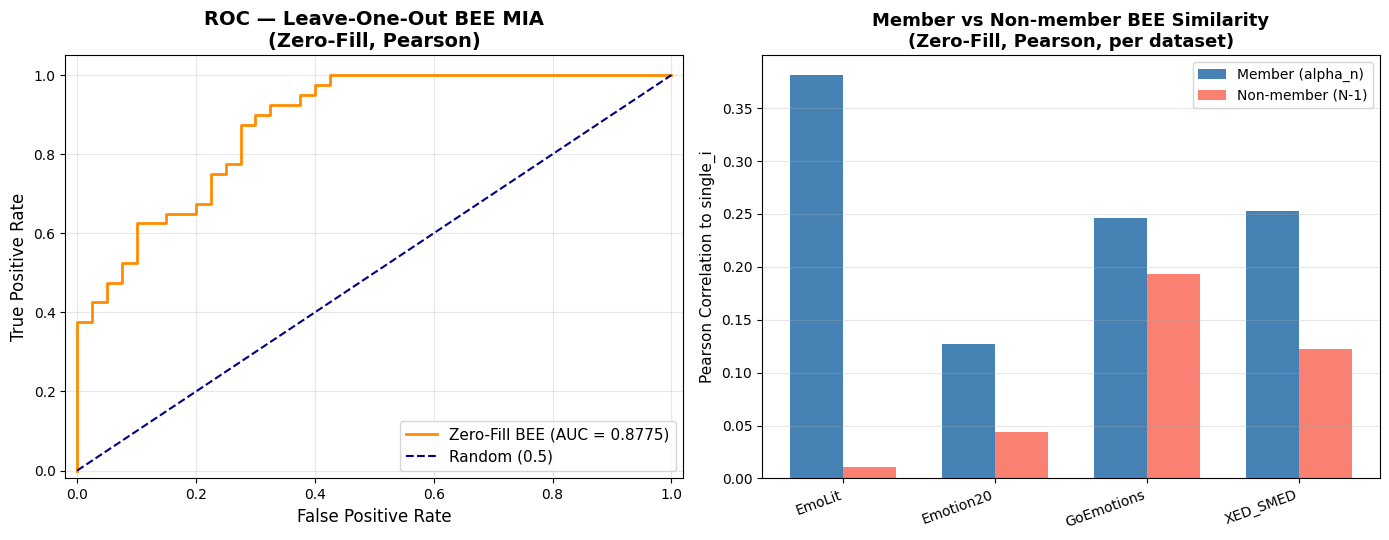


Leave-One-Out BEE MIA (Zero-Fill, Pearson)  —  AUC = 0.8775


In [ ]:
# ============================================================================
# Leave-One-Out MIA — ROC / AUC  (Zero-Fill BEE, Pearson)
# ============================================================================

from sklearn.metrics import roc_curve, auc

alpha_n_zf = aligned_matrices["alpha_n"]

def pearson_flat(a, b):
    """Pearson correlation between two 1-D arrays."""
    if np.std(a) < 1e-10 or np.std(b) < 1e-10:
        return 0.0
    return np.corrcoef(a, b)[0, 1]

# ── (A) Per-dataset flat scores ──
print("="*65)
print("Leave-One-Out MIA — Zero-Fill BEE Pearson Correlation")
print("="*65)
print(f"{'Dataset':<16} {'Member':>10} {'Non-member':>12} {'Delta':>8} {'Hit':>5}")
print("-"*55)

member_flat = []
nonmember_flat = []
for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    single_f = aligned_matrices[s_key].flatten()
    alpha_f  = alpha_n_zf.flatten()
    n1_f     = aligned_matrices[n1_key].flatten()

    m_score  = pearson_flat(alpha_f, single_f)
    nm_score = pearson_flat(n1_f, single_f)
    member_flat.append(m_score)
    nonmember_flat.append(nm_score)

    hit = "Y" if m_score > nm_score else " "
    print(f"{name:<16} {m_score:>10.4f} {nm_score:>12.4f} {m_score - nm_score:>+8.4f} {hit:>5}")

flat_accuracy = sum(m > n for m, n in zip(member_flat, nonmember_flat)) / len(DATASET_NAMES)
print(f"\nFlat accuracy: {flat_accuracy:.0%} ({sum(m > n for m, n in zip(member_flat, nonmember_flat))}/{len(DATASET_NAMES)})")

# ── (B) Per-emotion scores → ROC/AUC ──
member_scores = []
nonmember_scores = []

for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    for c_idx in range(len(CANONICAL_LABELS)):
        single_col = aligned_matrices[s_key][:, c_idx]
        alpha_col  = alpha_n_zf[:, c_idx]
        n1_col     = aligned_matrices[n1_key][:, c_idx]

        if np.std(single_col) < 1e-10:
            continue

        m_s  = pearson_flat(alpha_col, single_col)
        nm_s = pearson_flat(n1_col, single_col)
        member_scores.append(m_s)
        nonmember_scores.append(nm_s)

all_member    = member_flat + member_scores
all_nonmember = nonmember_flat + nonmember_scores

scores = np.array(all_member + all_nonmember)
labels = np.array([1]*len(all_member) + [0]*len(all_nonmember))

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

emo_hits = sum(m > n for m, n in zip(member_scores, nonmember_scores))
emo_total = len(member_scores)
print(f"Per-emotion accuracy: {emo_hits/emo_total:.1%} ({emo_hits}/{emo_total})")

# ── (C) Contribution-match score ──
print(f"\n{'='*65}")
print("Contribution Match: pearson(alpha_n - alpha_{n-1,no_i}, single_i)")
print("="*65)
for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    contrib = (alpha_n_zf - aligned_matrices[n1_key]).flatten()
    single  = aligned_matrices[s_key].flatten()
    pr = pearson_flat(contrib, single)
    print(f"  {name}: {pr:.4f}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"Zero-Fill BEE (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random (0.5)")
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC — Leave-One-Out BEE MIA\n(Zero-Fill, Pearson)", fontsize=14, fontweight="bold")
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, alpha=0.3)

x = np.arange(len(DATASET_NAMES))
w = 0.35
axes[1].bar(x - w/2, member_flat, w, label="Member (alpha_n)", color="steelblue")
axes[1].bar(x + w/2, nonmember_flat, w, label="Non-member (N-1)", color="salmon")
axes[1].set_xticks(x)
axes[1].set_xticklabels(DATASET_NAMES, rotation=20, ha="right")
axes[1].set_ylabel("Pearson Correlation to single_i", fontsize=11)
axes[1].set_title("Member vs Non-member BEE Similarity\n(Zero-Fill, Pearson, per dataset)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("BEE_MIA_LOO_ROC_AUC.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*65}")
print(f"Leave-One-Out BEE MIA (Zero-Fill, Pearson)  —  AUC = {roc_auc:.4f}")
print(f"{'='*65}")

Computing softmax BEE (zero-fill) for all models...
  alpha_n (197 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  n-1_no_EmoLit (196 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  n-1_no_Emotion20 (197 keywords)...


...

  single_GoEmotions (198 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  single_XED_SMED (197 keywords)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


All softmax BEE matrices computed. Shape: (535, 9)

Correlation: White-Box vs Softmax BEE (both Zero-Fill)
Model                       Pearson   Cosine
----------------------------------------------
  alpha_n                    0.6733   0.6912
  n-1_no_EmoLit              0.6537   0.6786
  n-1_no_Emotion20           0.6071   0.6336
  n-1_no_GoEmotions          0.6351   0.6651
  n-1_no_XED_SMED            0.6747   0.6857
  single_EmoLit              0.6219   0.6588
  single_Emotion20           0.6298   0.6559
  single_GoEmotions          0.6205   0.6485
  single_XED_SMED            0.6752   0.7121

Leave-One-Out MIA — Softmax Zero-Fill BEE (Pearson)
Dataset              Member   Non-member    Delta   Hit
-------------------------------------------------------
EmoLit               0.1108       0.0130  +0.0978     Y
Emotion20            0.0252      -0.0120  +0.0373     Y
GoEmotions           0.4072       0.3172  +0.0900     Y
XED_SMED             0.3250       0.1989  +0.1261     Y

Flat 

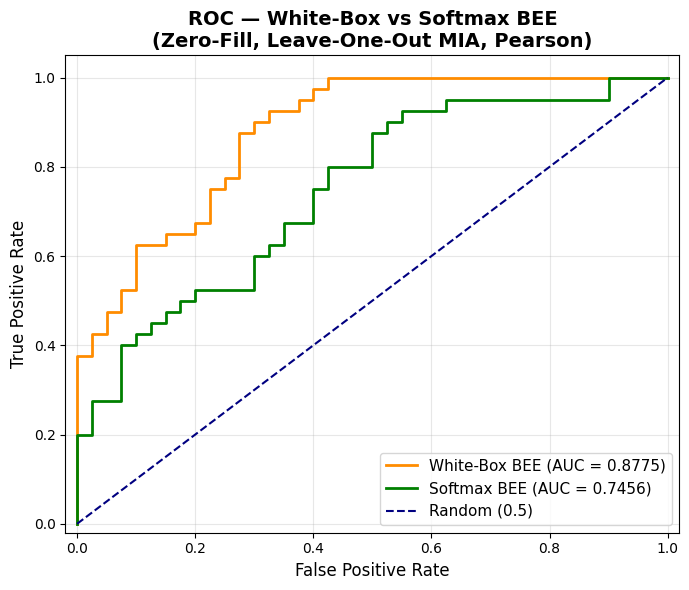


White-Box BEE AUC = 0.8775   |   Softmax BEE AUC = 0.7456


In [ ]:
# ============================================================================
# Black-Box Softmax BEE — Zero-Fill, No Weight Extraction (Pearson)
# ============================================================================

import torch
import torch.nn.functional as F
import gc

device = "cuda" if torch.cuda.is_available() else "cpu"

keyword_to_idx = {kw: i for i, kw in enumerate(union_keywords)}

def compute_softmax_bee_zerofill(model_path, own_keywords, batch_size=64):
    """
    Black-box BEE with zero-fill: compute softmax only for the model's OWN
    keywords, zero-fill the rest.
    Returns (len(union_keywords), 9) matrix.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    model_id2label = model.config.id2label
    num_model_labels = model.config.num_labels

    all_probs = []
    for i in range(0, len(own_keywords), batch_size):
        batch = own_keywords[i : i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                           max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    raw_probs = np.vstack(all_probs)

    # Min-subtract per keyword over classes
    raw_probs = raw_probs - raw_probs.min(axis=1, keepdims=True)

    # Zero-fill into union keyword x canonical label matrix
    softmax_matrix = np.zeros((len(union_keywords), len(CANONICAL_LABELS)))
    for local_idx, kw in enumerate(own_keywords):
        if kw not in keyword_to_idx:
            continue
        global_idx = keyword_to_idx[kw]
        if num_model_labels == len(CANONICAL_LABELS):
            softmax_matrix[global_idx, :] = raw_probs[local_idx, :]
        else:
            for model_class_idx, label_name in model_id2label.items():
                model_class_idx = int(model_class_idx)
                if label_name in CANONICAL_LABELS:
                    canon_idx = CANONICAL_LABELS.index(label_name)
                    softmax_matrix[global_idx, canon_idx] = raw_probs[local_idx, model_class_idx]

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return softmax_matrix

# ── Compute softmax BEE (zero-fill) for all models ──
print("Computing softmax BEE (zero-fill) for all models...")
softmax_zf = {}

for config_name, mpath in model_paths.items():
    own_kws = per_config_keywords[config_name]
    print(f"  {config_name} ({len(own_kws)} keywords)...")
    softmax_zf[config_name] = compute_softmax_bee_zerofill(mpath, own_kws)

print(f"\nAll softmax BEE matrices computed. Shape: {softmax_zf['alpha_n'].shape}")

# ── Validate: correlation white-box vs softmax (zero-fill) ──
print("\n" + "="*60)
print("Correlation: White-Box vs Softmax BEE (both Zero-Fill)")
print("="*60)
print(f"{'Model':<26} {'Pearson':>8} {'Cosine':>8}")
print("-"*46)

for config_name in model_paths:
    wb_flat = aligned_matrices[config_name].flatten()
    sb_flat = softmax_zf[config_name].flatten()
    if np.std(wb_flat) < 1e-10 or np.std(sb_flat) < 1e-10:
        print(f"  {config_name:<24} {'N/A':>8} {'N/A':>8}")
        continue
    pearson_r = np.corrcoef(wb_flat, sb_flat)[0, 1]
    cos_s = sklearn_cosine_sim(wb_flat.reshape(1, -1), sb_flat.reshape(1, -1))[0, 0]
    print(f"  {config_name:<24} {pearson_r:>8.4f} {cos_s:>8.4f}")

# ── Leave-one-out MIA with softmax zero-fill (Pearson) ──
print("\n" + "="*60)
print("Leave-One-Out MIA — Softmax Zero-Fill BEE (Pearson)")
print("="*60)

def pearson_flat(a, b):
    if np.std(a) < 1e-10 or np.std(b) < 1e-10:
        return 0.0
    return np.corrcoef(a, b)[0, 1]

alpha_sb = softmax_zf["alpha_n"]

sb_member_flat = []
sb_nonmember_flat = []
sb_member_emo = []
sb_nonmember_emo = []

print(f"{'Dataset':<16} {'Member':>10} {'Non-member':>12} {'Delta':>8} {'Hit':>5}")
print("-"*55)

for name, n1_key, s_key in zip(DATASET_NAMES, N1_KEYS, SINGLE_KEYS):
    single_sb = softmax_zf[s_key].flatten()
    alpha_sb_flat = alpha_sb.flatten()
    n1_sb = softmax_zf[n1_key].flatten()

    m_s  = pearson_flat(alpha_sb_flat, single_sb)
    nm_s = pearson_flat(n1_sb, single_sb)
    sb_member_flat.append(m_s)
    sb_nonmember_flat.append(nm_s)

    hit = "Y" if m_s > nm_s else " "
    print(f"{name:<16} {m_s:>10.4f} {nm_s:>12.4f} {m_s - nm_s:>+8.4f} {hit:>5}")

    for c_idx in range(len(CANONICAL_LABELS)):
        s_col = softmax_zf[s_key][:, c_idx]
        a_col = alpha_sb[:, c_idx]
        n_col = softmax_zf[n1_key][:, c_idx]
        if np.std(s_col) < 1e-10:
            continue
        sb_member_emo.append(pearson_flat(a_col, s_col))
        sb_nonmember_emo.append(pearson_flat(n_col, s_col))

sb_all_m  = sb_member_flat + sb_member_emo
sb_all_nm = sb_nonmember_flat + sb_nonmember_emo
sb_scores = np.array(sb_all_m + sb_all_nm)
sb_labels = np.array([1]*len(sb_all_m) + [0]*len(sb_all_nm))

sb_fpr, sb_tpr, _ = roc_curve(sb_labels, sb_scores)
sb_auc = auc(sb_fpr, sb_tpr)

sb_flat_acc = sum(m > n for m, n in zip(sb_member_flat, sb_nonmember_flat)) / len(DATASET_NAMES)
sb_emo_hits = sum(m > n for m, n in zip(sb_member_emo, sb_nonmember_emo))
print(f"\nFlat accuracy: {sb_flat_acc:.0%}")
if len(sb_member_emo) > 0:
    print(f"Per-emotion accuracy: {sb_emo_hits/len(sb_member_emo):.1%} ({sb_emo_hits}/{len(sb_member_emo)})")

# ── Plot both ROC curves ──
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"White-Box BEE (AUC = {roc_auc:.4f})")
ax.plot(sb_fpr, sb_tpr, color="green", lw=2, label=f"Softmax BEE (AUC = {sb_auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random (0.5)")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC — White-Box vs Softmax BEE\n(Zero-Fill, Leave-One-Out MIA, Pearson)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("BEE_MIA_ROC_whitebox_vs_softmax.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*60}")
print(f"White-Box BEE AUC = {roc_auc:.4f}   |   Softmax BEE AUC = {sb_auc:.4f}")
print(f"{'='*60}")